# CTD / Glider Data Analysis
**IIMS Sensor Processing Project — WS 2025/26**

Dataset: SLOCUM G3 glider, Atlantic Ocean  
Task: Identify structure of density distribution

---
Sections:
1. Setup & data loading
2. Data inspection
3. Preprocessing & derived variables
4. Profile plotter (single dive)
5. Section plotter (2D transect)
6. T-S diagram
7. Buoyancy frequency N²

## 0 — Install dependencies (run once)
```bash
pip install gsw cmocean matplotlib pandas numpy scipy
```

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cmocean
import gsw
from scipy.ndimage import gaussian_filter1d

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

## 1 — Data loading

**Replace the dummy-data block below with your real data loader once the dataset arrives.**

Expected columns after loading:
| column | unit | description |
|--------|------|-------------|
| `time` | datetime64 | UTC timestamp |
| `lat` | °N | latitude |
| `lon` | °E | longitude |
| `depth` | m (positive down) | pressure-derived depth |
| `pressure` | dbar | measured pressure |
| `temperature` | °C | in-situ temperature |
| `salinity` | PSU | practical salinity |
| `dive_id` | int | dive number (assigned during preprocessing) |

In [3]:
# ── REAL DATA LOADER (uncomment when data is available) ────────────────────
# df = pd.read_csv('data/glider_ctd.csv', parse_dates=['time'])
# df = df.rename(columns={'temp': 'temperature', 'sal': 'salinity', ...})
# ───────────────────────────────────────────────────────────────────────────

# ── DUMMY DATA (realistic Atlantic glider section) ─────────────────────────
rng = np.random.default_rng(42)

N_DIVES = 30
DEPTHS_PER_DIVE = 200

# Glider moves ~0.3° latitude per dive
dive_lats = np.linspace(10.0, 18.0, N_DIVES)   # 10°N → 18°N transect
dive_lons = np.full(N_DIVES, -25.0)             # fixed ~25°W

records = []
t0 = pd.Timestamp('2024-09-01')

for i, (lat, lon) in enumerate(zip(dive_lats, dive_lons)):
    depths = np.linspace(0, 1000, DEPTHS_PER_DIVE)
    pressures = gsw.p_from_z(-depths, lat)

    # --- realistic vertical structure (dummy) ---
    # Mixed layer ~80 m, thermocline ~80-400 m, deep water below
    T_surface = 24.0 - 0.3 * (lat - 10)          # warmer at low latitudes
    T_deep    = 3.0
    ml_depth  = 80.0
    thermo_scale = 200.0
    temperature = T_deep + (T_surface - T_deep) * np.exp(
        -np.maximum(depths - ml_depth, 0) / thermo_scale
    )
    temperature[:int(ml_depth * DEPTHS_PER_DIVE / 1000)] = T_surface
    temperature += rng.normal(0, 0.05, len(depths))

    # Salinity: AAIW minimum ~800 m, NADW maximum ~1500 m (shallow here)
    S_surface = 36.5 - 0.05 * (lat - 10)
    S_deep    = 34.9
    salinity  = S_deep + (S_surface - S_deep) * np.exp(-depths / 300)
    # AAIW-like freshwater tongue around 600–900 m
    aaiw_mask = np.exp(-0.5 * ((depths - 750) / 120) ** 2)
    salinity  -= 0.3 * aaiw_mask
    salinity  += rng.normal(0, 0.02, len(depths))

    times = [t0 + pd.Timedelta(hours=i * 8 + j * 8 / DEPTHS_PER_DIVE)
             for j in range(DEPTHS_PER_DIVE)]

    for j in range(DEPTHS_PER_DIVE):
        records.append({
            'time':        times[j],
            'lat':         lat,
            'lon':         lon,
            'depth':       depths[j],
            'pressure':    pressures[j],
            'temperature': temperature[j],
            'salinity':    salinity[j],
            'dive_id':     i,
        })

df = pd.DataFrame(records)
print(f"Loaded {len(df):,} measurements across {df['dive_id'].nunique()} dives")
df.head()

Loaded 6,000 measurements across 30 dives


,time,lat,lon,depth,pressure,temperature,salinity,dive_id
0,2024-09-01 00:00:00,10.0,-25.0,0.000000,0.000000,24.015236,36.506751,0
1,2024-09-01 00:02:24,10.0,-25.0,5.025126,5.053742,23.948001,36.501572,0
2,2024-09-01 00:04:48,10.0,-25.0,10.050251,10.107609,24.037523,36.449098,0
3,2024-09-01 00:07:12,10.0,-25.0,15.075377,15.161599,24.047028,36.434463,0
4,2024-09-01 00:09:36,10.0,-25.0,20.100503,20.215713,23.902448,36.355306,0


## 2 — Data inspection

In [4]:
print(df.dtypes)
print()
print(df[['depth', 'pressure', 'temperature', 'salinity']].describe().round(3))

time           datetime64[ns]
lat                   float64
lon                   float64
depth                 float64
pressure              float64
temperature           float64
salinity              float64
dive_id                 int64
dtype: object

          depth  pressure  temperature  salinity
count  6000.000  6000.000     6000.000  6000.000
mean    500.000   503.738        8.526    35.218
std     290.146   292.551        6.384     0.442
min       0.000     0.000        3.100    34.647
25%     250.000   251.595        3.691    34.839
50%     500.000   503.540        5.427    35.129
75%     750.000   755.833       11.491    35.512
max    1000.000  1008.474       24.056    36.507


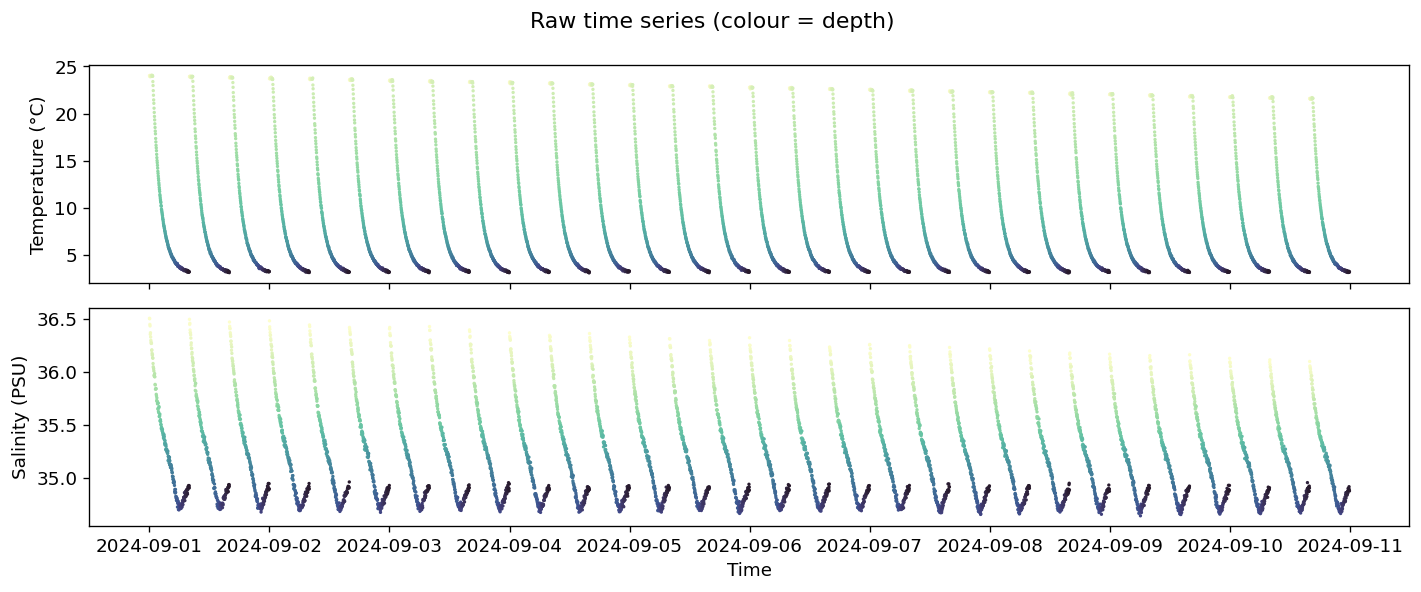

In [5]:
# Quick sanity plots — raw time series of T and S
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].scatter(df['time'], df['temperature'], c=df['depth'], cmap=cmocean.cm.deep,
                s=1, rasterized=True)
axes[0].set_ylabel('Temperature (°C)')
axes[1].scatter(df['time'], df['salinity'], c=df['depth'], cmap=cmocean.cm.deep,
                s=1, rasterized=True)
axes[1].set_ylabel('Salinity (PSU)')
axes[1].set_xlabel('Time')
fig.suptitle('Raw time series (colour = depth)')
plt.tight_layout()

## 3 — Preprocessing & derived variables

In [6]:
# ── Outlier removal (simple IQR filter per variable) ───────────────────────
def iqr_filter(series, k=3.0):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return series.between(q1 - k * iqr, q3 + k * iqr)

mask = iqr_filter(df['temperature']) & iqr_filter(df['salinity'])
n_removed = (~mask).sum()
df = df[mask].copy()
print(f"Removed {n_removed} outliers ({n_removed/len(mask)*100:.2f}%)")

Removed 0 outliers (0.00%)


In [7]:
# ── Derived variables via gsw (TEOS-10) ────────────────────────────────────

# Absolute Salinity and Conservative Temperature (TEOS-10 standards)
df['SA'] = gsw.SA_from_SP(df['salinity'], df['pressure'], df['lon'], df['lat'])
df['CT'] = gsw.CT_from_t(df['SA'], df['temperature'], df['pressure'])

# Potential density anomaly σ₀ = ρ(SA, CT, p=0) − 1000  [kg/m³]
df['sigma0'] = gsw.sigma0(df['SA'], df['CT'])

# In-situ density (for N² calculation)
df['rho'] = gsw.rho(df['SA'], df['CT'], df['pressure'])

print(df[['SA', 'CT', 'sigma0', 'rho']].describe().round(4))

              SA         CT     sigma0        rho
count  6000.0000  6000.0000  6000.0000  6000.0000
mean     35.3872     8.4704    27.1628  1029.4742
std       0.4424     6.3858     0.9283     2.1601
min      34.8141     3.0302    24.5097  1024.7733
25%      35.0068     3.6332    27.0844  1028.1943
50%      35.2980     5.3773    27.6245  1030.0498
75%      35.6812    11.4387    27.7094  1031.0991
max      36.6792    23.9978    27.8504  1032.5092


In [15]:
# ── Assign distance along track (km from first dive) ──────────────────────
lat0 = df['lat'].min()
lon0 = df['lon'].iloc[0]
# simple flat-Earth approximation; replace with gsw.distance for accuracy
df['dist_km'] = gsw.distance(
    np.column_stack([df['lon'], df['lat']]),
    axis=0
).cumsum()[0] / 1000 if False else (
    # fallback: degrees * 111 km/deg
    np.sqrt(((df['lat'] - lat0) * 111)**2 + ((df['lon'] - lon0) * 111 * np.cos(np.radians(lat0)))**2)
)
print(f"Section length: {df['dist_km'].max():.1f} km")

Section length: 888.0 km


## 4 — Profile plotter (single dive)

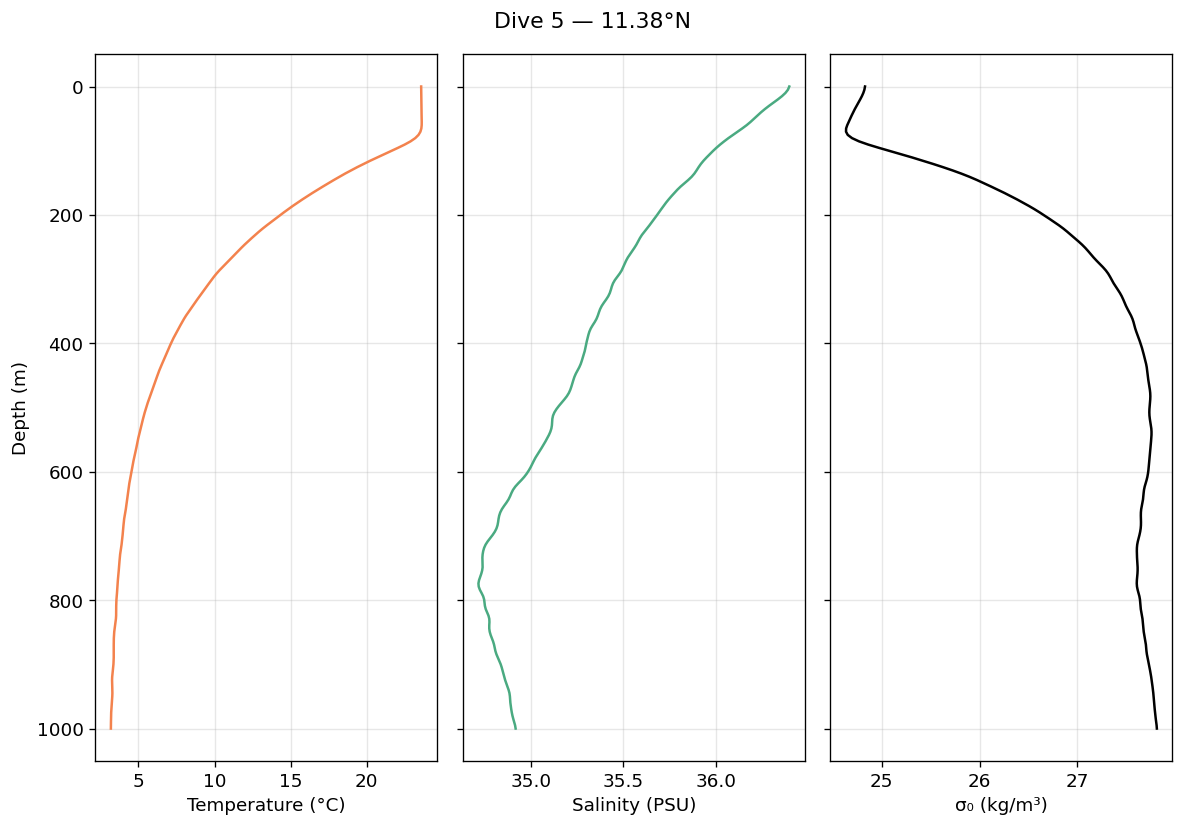

In [16]:
def plot_profile(df, dive_id, smooth_sigma=2):
    """T, S, σ₀ vs depth for one dive."""
    d = df[df['dive_id'] == dive_id].sort_values('depth')

    T = gaussian_filter1d(d['temperature'].values, smooth_sigma)
    S = gaussian_filter1d(d['salinity'].values, smooth_sigma)
    sig = gaussian_filter1d(d['sigma0'].values, smooth_sigma)
    z = d['depth'].values

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 7), sharey=True)

    ax1.plot(T, z, color=cmocean.cm.thermal(0.7), lw=1.5)
    ax1.set_xlabel('Temperature (°C)')
    ax1.set_ylabel('Depth (m)')
    ax1.invert_yaxis()
    ax1.grid(alpha=0.3)

    ax2.plot(S, z, color=cmocean.cm.haline(0.6), lw=1.5)
    ax2.set_xlabel('Salinity (PSU)')
    ax2.grid(alpha=0.3)

    ax3.plot(sig, z, color='k', lw=1.5)
    ax3.set_xlabel('σ₀ (kg/m³)')
    ax3.grid(alpha=0.3)

    lat = d['lat'].iloc[0]
    fig.suptitle(f'Dive {dive_id} — {lat:.2f}°N')
    plt.tight_layout()
    return fig

# ── Change dive_id to inspect different dives ──────────────────────────────
DIVE_TO_PLOT = 5
fig = plot_profile(df, DIVE_TO_PLOT)

## 5 — Section plotter (2D transect)

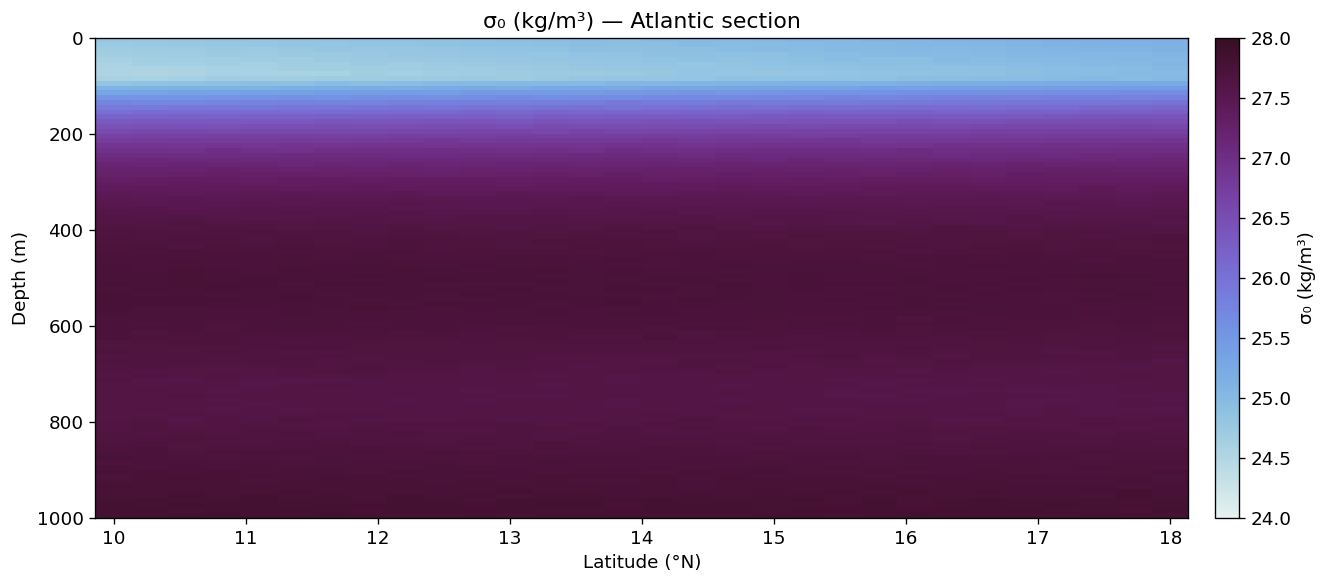

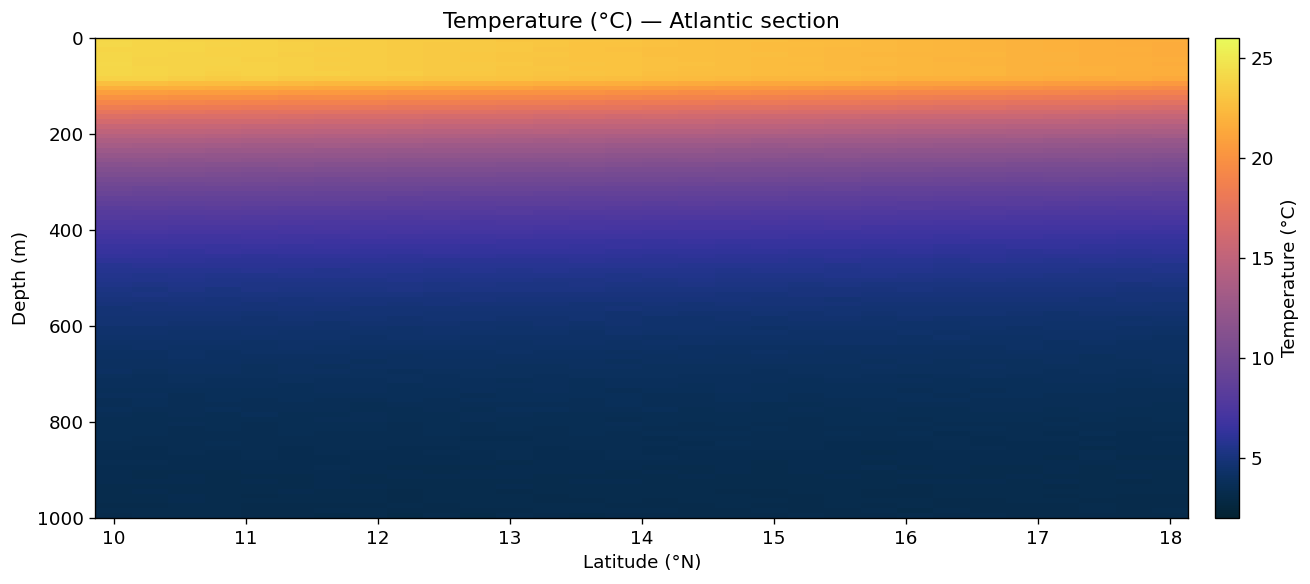

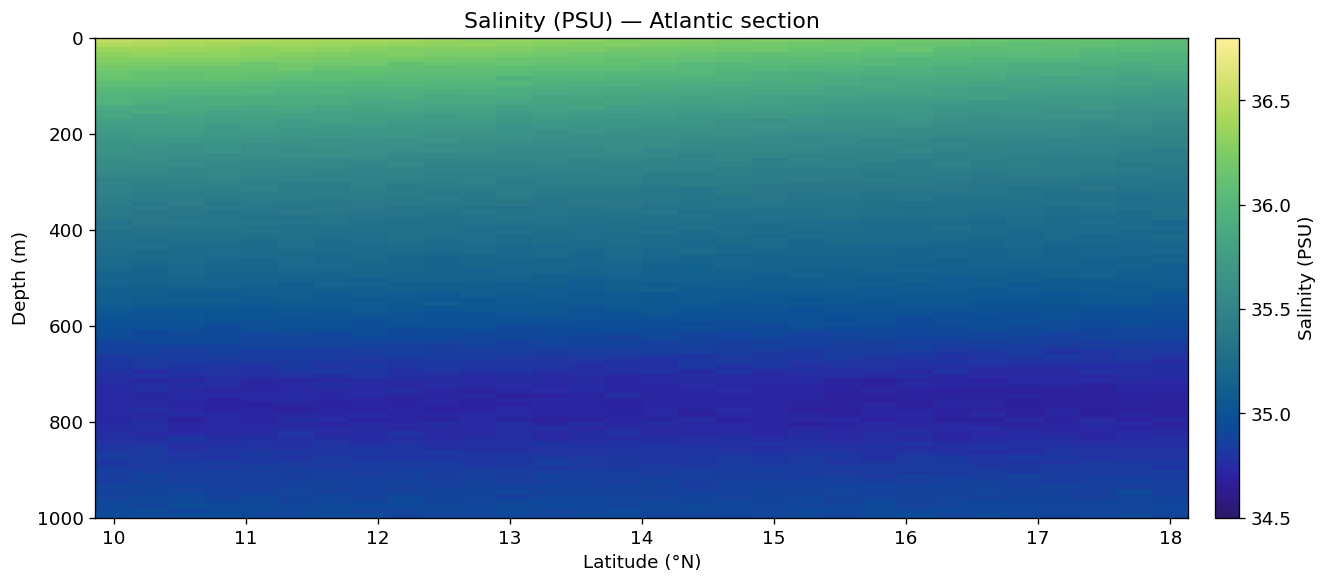

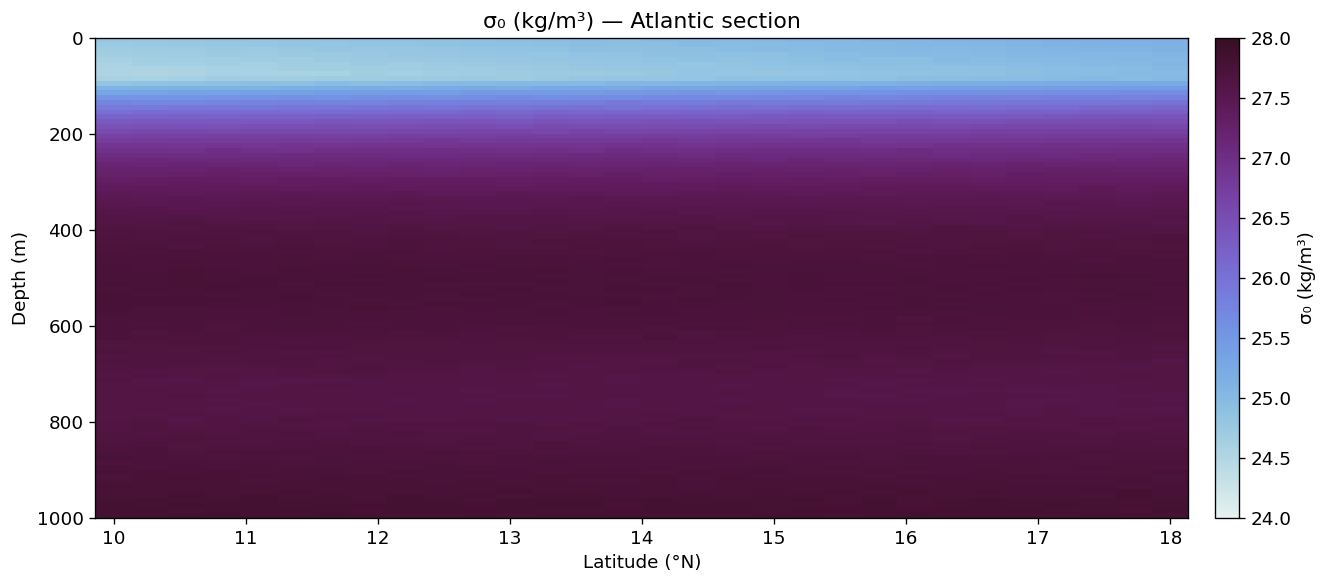

In [ ]:
def make_section_grid(df, var, depth_bins=None, x_col='lat'):
    """Bin data onto a regular depth × position grid for section plots."""
    if depth_bins is None:
        depth_bins = np.arange(0, df['depth'].max() + 10, 10)

    x_vals = sorted(df[x_col].unique())
    grid = np.full((len(depth_bins) - 1, len(x_vals)), np.nan)

    for j, x in enumerate(x_vals):
        col = df[df[x_col] == x].copy()
        for i in range(len(depth_bins) - 1):
            mask = (col['depth'] >= depth_bins[i]) & (col['depth'] < depth_bins[i + 1])
            if mask.any():
                grid[i, j] = col.loc[mask, var].mean()

    depth_centres = 0.5 * (depth_bins[:-1] + depth_bins[1:])
    return grid, depth_centres, np.array(x_vals)


def plot_section(df, var, cmap, label, vmin=None, vmax=None,
                 depth_bins=None, x_col='lat', x_label='Latitude (°N)'):
    grid, depths, x_vals = make_section_grid(df, var, depth_bins, x_col)

    fig, ax = plt.subplots(figsize=(12, 5))
    im = ax.pcolormesh(
        x_vals, depths, grid,
        cmap=cmap, vmin=vmin, vmax=vmax,
        shading='auto'
    )
    plt.colorbar(im, ax=ax, label=label, pad=0.02)
    ax.set_xlabel(x_label)
    ax.set_ylabel('Depth (m)')
    ax.invert_yaxis()
    ax.set_title(f'{label} — Atlantic section')
    plt.tight_layout()
    return fig

#vmin=df['temperature'].quantile(0.02), vmax=df['temperature'].quantile(0.98)

# Temperature section
plot_section(df, 'temperature', cmocean.cm.thermal, 'Temperature (°C)',
             vmin=2, vmax=26)

# Salinity section
plot_section(df, 'salinity', cmocean.cm.haline, 'Salinity (PSU)',
             vmin=34.5, vmax=36.8)

# Density anomaly σ₀ section
plot_section(df, 'sigma0', cmocean.cm.dense, 'σ₀ (kg/m³)',
             vmin=24, vmax=28)

## 6 — T-S diagram (water mass identification)

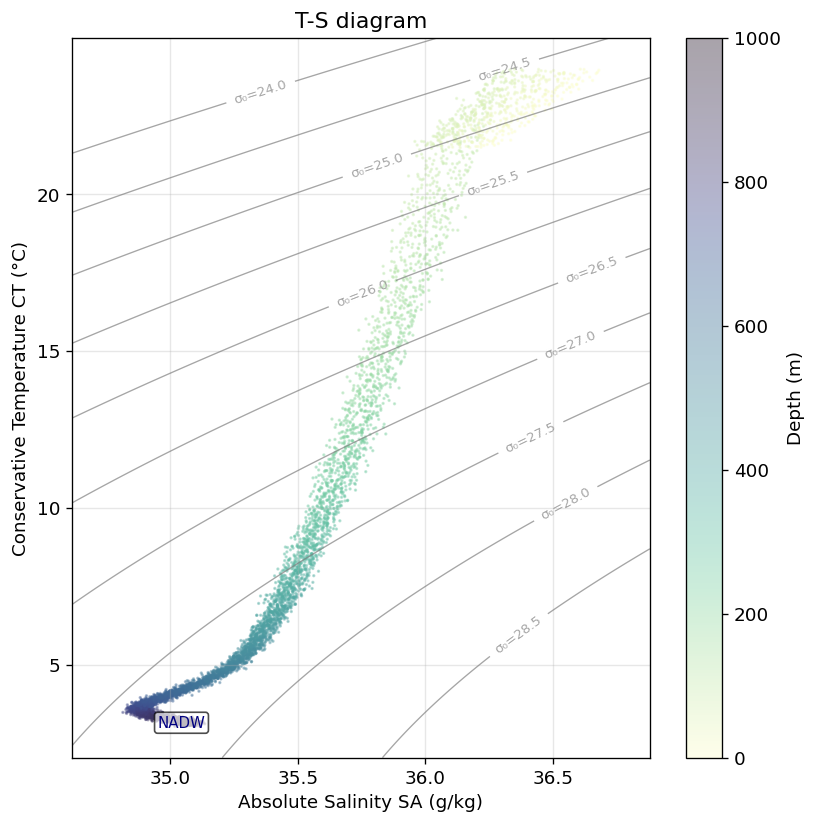

In [18]:
# ── Isopycnal contours (σ₀ lines) ─────────────────────────────────────────
T_range = np.linspace(df['CT'].min() - 1, df['CT'].max() + 1, 200)
S_range = np.linspace(df['SA'].min() - 0.2, df['SA'].max() + 0.2, 200)
T_grid, S_grid = np.meshgrid(T_range, S_range)
sigma_grid = gsw.sigma0(S_grid, T_grid)

fig, ax = plt.subplots(figsize=(7, 7))

# Scatter coloured by depth
sc = ax.scatter(
    df['SA'], df['CT'],
    c=df['depth'], cmap=cmocean.cm.deep,
    s=1, alpha=0.4, rasterized=True
)
plt.colorbar(sc, ax=ax, label='Depth (m)')

# Isopycnals
sigma_levels = np.arange(24, 29, 0.5)
cs = ax.contour(S_grid, T_grid, sigma_grid,
                levels=sigma_levels, colors='grey', linewidths=0.8, alpha=0.7)
ax.clabel(cs, fmt='σ₀=%.1f', fontsize=8)

# Water mass labels (approximate Atlantic values — adjust to your data)
water_masses = {
    'AAIW':  (34.2, 4.5),    # S~34.2, T~4.5°C, ~800m
    'NADW':  (34.95, 3.0),   # S~34.95, T~3°C, ~2000m
    'AABW':  (34.68, 0.5),   # S~34.68, T<1°C, >4000m
}
for name, (s, t) in water_masses.items():
    ax.annotate(name, xy=(s, t), fontsize=9, color='navy',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))

ax.set_xlabel('Absolute Salinity SA (g/kg)')
ax.set_ylabel('Conservative Temperature CT (°C)')
ax.set_title('T-S diagram')
ax.grid(alpha=0.3)
plt.tight_layout()

## 7 — Buoyancy frequency N²

In [19]:
def compute_N2_profile(dive_df):
    """Compute N² for one dive using gsw.Nsquared."""
    d = dive_df.sort_values('pressure')
    N2, p_mid = gsw.Nsquared(
        d['SA'].values,
        d['CT'].values,
        d['pressure'].values,
        lat=d['lat'].values[:-1]
    )
    z_mid = -gsw.z_from_p(p_mid, d['lat'].values[:-1])
    return N2, z_mid


def plot_N2_profile(df, dive_id):
    d = df[df['dive_id'] == dive_id]
    N2, z_mid = compute_N2_profile(d)

    N2_smooth = gaussian_filter1d(np.maximum(N2, 0), sigma=3)

    fig, ax = plt.subplots(figsize=(5, 7))
    ax.plot(N2_smooth * 1e4, z_mid, color='steelblue', lw=1.5,
            label='N² (×10⁻⁴ s⁻²)')
    ax.axvline(0, color='k', lw=0.8, ls='--')
    ax.set_xlabel('N² (×10⁻⁴ s⁻²)')
    ax.set_ylabel('Depth (m)')
    ax.invert_yaxis()
    ax.set_title(f'Buoyancy frequency — Dive {dive_id}')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    return fig


plot_N2_profile(df, DIVE_TO_PLOT)

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (200,) and arg 3 with shape (199,).

## 8 — Save figures

Uncomment to export all figures for the report.

In [ ]:
# import os
# os.makedirs('figures', exist_ok=True)
# for i, fig in enumerate(plt.get_fignums()):
#     plt.figure(fig).savefig(f'figures/fig_{i:02d}.pdf', bbox_inches='tight')